# UK E-Commerce Sales & Customer Analysis

## Exploratory Data Analysis and Business Insights

### Project Overview
This project analyzes transactional data from a UK-based online retailer
to understand revenue performance, product demand, customer behaviour,
geographic performance, sales trends, and unusual transactions.

### Business Objective
The objective is to transform raw transactional data into actionable
commercial insights that can support decisions related to product strategy,
customer management, international markets, and inventory planning.

### Key Questions
1. How much revenue did the business generate?
2. Which products drive revenue and sales volume?
3. Which products underperform or sell infrequently?
4. Who are the highest-value customers?
5. How does revenue change over time?
6. Which geographic markets generate the most revenue?
7. Are there unusual transactions requiring investigation?

In [1]:
# import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

pd.set_option('display.max_columns', None) 

In [2]:
# load the dataset
DATA_PATH = 'data.csv'

df = pd.read_csv(DATA_PATH, encoding='latin-1') 
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape # Display the shape of the dataframe (number of rows and columns)

(541909, 8)

## Initial Inspection

In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 541,909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data Dictionary:

| Column      | Description                           |
| ----------- | ------------------------------------- |
| InvoiceNo   | Unique invoice/transaction identifier |
| StockCode   | Product identifier                    |
| Description | Product description                   |
| Quantity    | Number of units                       |
| InvoiceDate | Transaction date and time             |
| UnitPrice   | Price per unit                        |
| CustomerID  | Customer identifier                   |
| Country     | Customer country                      |


In [7]:
quality_summary = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().mean() * 100).round(2),
    "Unique_Values": df.nunique()
})

quality_summary

,Data_Type,Missing_Count,Missing_Percent,Unique_Values
InvoiceNo,object,0,0.00,25900
StockCode,object,0,0.00,4070
Description,object,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,object,0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4372
Country,object,0,0.00,38


In [8]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate rate: {duplicate_count / len(df) * 100:.2f}%")

Duplicate rows: 5,268
Duplicate rate: 0.97%


In [9]:
df[df.duplicated(keep=False)].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


Exact duplicate records were identified and removed to prevent double-counting revenue and quantities.

## Data Cleaning & Validation

In [10]:
initial_rows = len(df)
duplicates = df.duplicated().sum()

df_clean = df.drop_duplicates().copy()

print(f"Initial rows: {initial_rows:,}")
print(f"Duplicates removed: {duplicates:,}")
print(f"Rows after duplicate removal: {len(df_clean):,}")

Initial rows: 541,909
Duplicates removed: 5,268
Rows after duplicate removal: 536,641


In [11]:
negative_qty = df_clean[df_clean["Quantity"] < 0]
negative_price = df_clean[df_clean["UnitPrice"] < 0]
zero_price = df_clean[df_clean["UnitPrice"] == 0]

print(f"Negative quantity rows: {len(negative_qty):,}")
print(f"Negative price rows: {len(negative_price):,}")
print(f"Zero-price rows: {len(zero_price):,}")

Negative quantity rows: 10,587
Negative price rows: 2
Zero-price rows: 2,510


In [12]:
zero_price_transactions = df_clean[df_clean["UnitPrice"] == 0]

zero_price_transactions[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "CustomerID"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
622,536414,22139,NaN,56,0.0,NaN
1970,536545,21134,NaN,1,0.0,NaN
1971,536546,22145,NaN,1,0.0,NaN
1972,536547,37509,NaN,1,0.0,NaN
1987,536549,85226A,NaN,1,0.0,NaN
1988,536550,85044,NaN,1,0.0,NaN
2024,536552,20950,NaN,1,0.0,NaN
2025,536553,37461,NaN,3,0.0,NaN
2026,536554,84670,NaN,23,0.0,NaN
2406,536589,21777,NaN,-10,0.0,NaN


In [13]:
df_clean["Has_CustomerID"] = df_clean["CustomerID"].notna()

Transactions without CustomerID were retained for aggregate sales and product analysis because they still contain valid transactional information. They were excluded only from analyses requiring customer identification, such as customer ranking and RFM segmentation.

In [14]:
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)

In [15]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [16]:
print(df_clean["InvoiceDate"].min())
print(df_clean["InvoiceDate"].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


In [17]:
df_clean[df_clean.isna().any(axis=1)].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Has_CustomerID
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,False
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,False
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,False
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,False
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,False
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom,False
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,False
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom,False
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom,False
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom,False


| Cleaning Step       | Records Affected | Decision                          |
| ------------------- | ---------------: | --------------------------------- |
| Exact duplicates    |                X | Removed                           |
| Negative quantities |                X | Excluded from sales analysis      |
| Negative prices     |                X | Investigated/excluded             |
| Zero prices         |                X | Investigated separately           |
| Missing CustomerID  |                X | Retained except customer analysis |


## Feature engineering

In [18]:
# Creating revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice'] # Create a new column 'Revenue' by multiplying 'Quantity' and 'UnitPrice' to calculate the revenue for each transaction

In [20]:
# Extracting date features from the 'InvoiceDate' column
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Month_Name"] = df_clean["InvoiceDate"].dt.month_name()
df_clean["Year_Month"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)
df_clean["Weekday"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour
df_clean["Order_Date"] = df_clean["InvoiceDate"].dt.date
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Has_CustomerID,Revenue,Year,Month,Month_Name,Year_Month,Weekday,Hour,Order_Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,True,15.30,2010,12,December,2010-12,Wednesday,8,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,2010,12,December,2010-12,Wednesday,8,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,True,22.00,2010,12,December,2010-12,Wednesday,8,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,2010,12,December,2010-12,Wednesday,8,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,2010,12,December,2010-12,Wednesday,8,2010-12-01


## Exploratory Data Analysis (Visuals   )

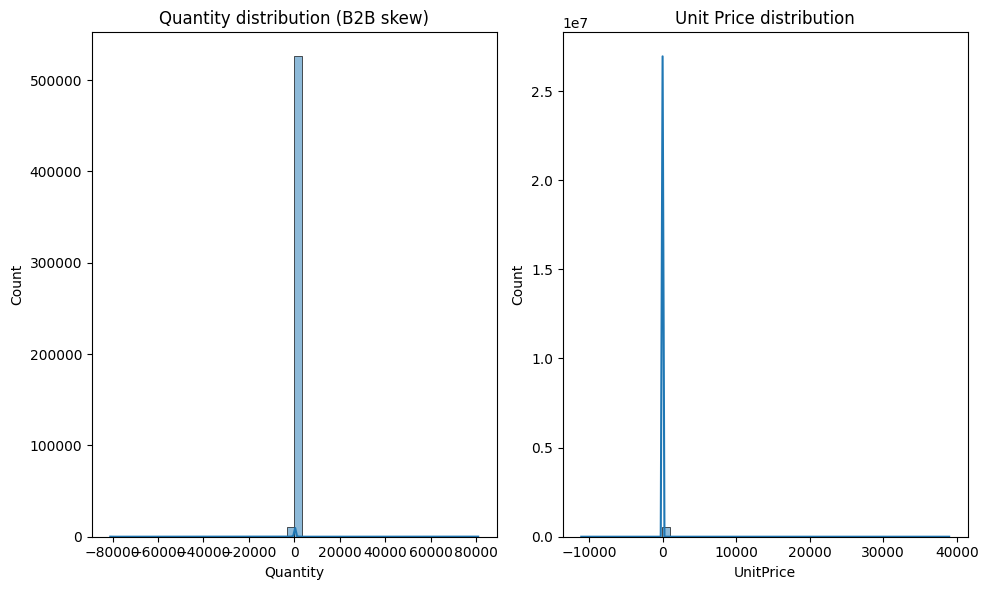

In [21]:
# Focus 1: Distribution of Revenue(Quantity * UnitPrice)
fig, ax = plt.subplots(1, 2, figsize=(10, 6)) # Create a new figure and axis for the plot
sns.histplot(df_clean['Quantity'], bins=50, kde=True, ax=ax[0]).set_title('Quantity distribution (B2B skew)') # Plot a histogram of the 'Quantity' column with 50 bins and a kernel density estimate (KDE) overlay
sns.histplot(df_clean['UnitPrice'], bins=50, kde=True, ax=ax[1]).set_title('Unit Price distribution') # Plot a histogram of the 'UnitPrice' column with 50 bins and a kernel density estimate (KDE) overlay 
plt.tight_layout() # Adjust the layout of the plot to prevent overlap
plt.show() # Display the plot

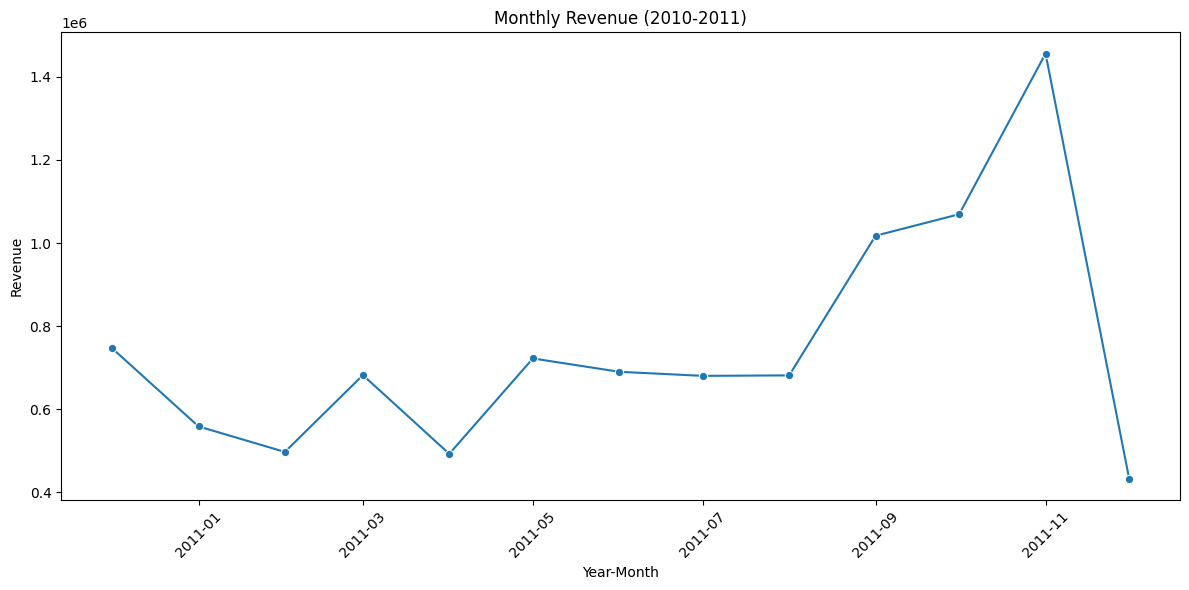

In [22]:
# Focus 2: Frequency of transactions over time(Monthly)
monthly_sales = df_clean.groupby(['Year', 'Month'])['Revenue'].sum().reset_index() # Group the cleaned dataframe by 'Year' and 'Month', sum the 'Revenue' for each group, and reset the index
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(DAY=1)) # Create a new column 'YearMonth' by combining 'Year' and 'Month' and setting the day to 1
plt.figure(figsize=(12, 6)) # Create a new figure with specified size   
monthly_sales_plot = sns.lineplot(data=monthly_sales, x='YearMonth', y='Revenue', marker='o') # Plot a line graph of monthly revenue over time
monthly_sales_plot.set_title('Monthly Revenue (2010-2011)') # Set the title of the plot
plt.xlabel('Year-Month') # Set the x-axis label
plt.ylabel('Revenue') # Set the y-axis label
plt.xticks(rotation=45) # Rotate the x-axis labels by 45 degrees
plt.tight_layout() # Adjust the layout of the plot to prevent overlap
plt.show() # Display the plot

C:\Users\danie\AppData\Local\Temp\ipykernel_20220\3163950169.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_rev.values, y=country_rev.index, palette='viridis') # Plot a horizontal bar chart of the top countries by revenue


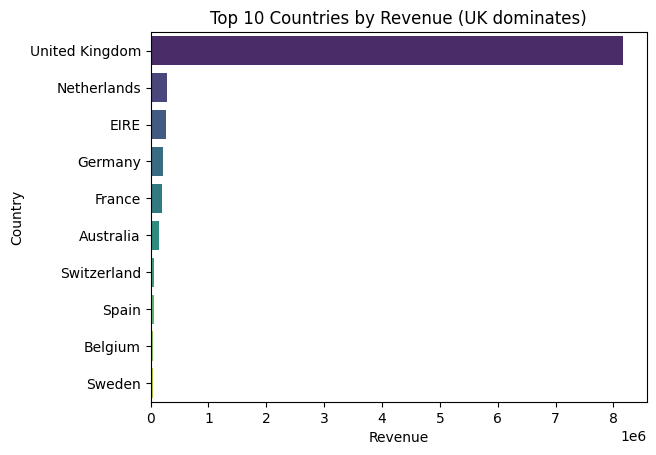

In [23]:
# Focus 3: Top Countries to see international sales
country_rev = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10) # Group the cleaned dataframe by 'Country', sum the 'Revenue' for each country, and sort in descending order to pick the top 10 countries by revenue
sns.barplot(x=country_rev.values, y=country_rev.index, palette='viridis') # Plot a horizontal bar chart of the top countries by revenue    
plt.title('Top 10 Countries by Revenue (UK dominates)') # Set the title of the plot
plt.xlabel('Revenue') # Set the x-axis label
plt.ylabel('Country') # Set the y-axis label
plt.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_20220\2050440868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_without_uk.values, y=country_without_uk.index, palette='viridis') # Plot a horizontal bar chart of the top countries by revenue


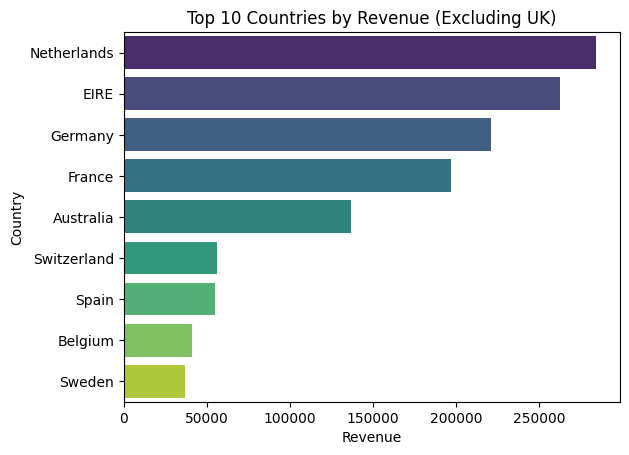

In [24]:
# Focus 3: Top Countries (Excluding UK to see international sales)
country_total = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10) # Group the cleaned dataframe by 'Country', sum the 'Revenue' for each country, and sort in descending order to pick the top 10 countries by revenue
country_without_uk = country_total[country_total.index != 'United Kingdom'] # Exclude the United Kingdom from the country revenue dataframe
sns.barplot(x=country_without_uk.values, y=country_without_uk.index, palette='viridis') # Plot a horizontal bar chart of the top countries by revenue    
plt.title('Top 10 Countries by Revenue (Excluding UK)') # Set the title of the plot
plt.xlabel('Revenue') # Set the x-axis label
plt.ylabel('Country') # Set the y-axis label
plt.show()

AVERAGE ORDER VALUE BY COUNTRY (min. 10 orders)
        Country  Total_Revenue  Total_Orders         AOV  Revenue_per_Customer
    Netherlands      284661.54           101 2818.431089          31629.060000
      Australia      137009.77            69 1985.648841          15223.307778
          Japan       35340.62            28 1262.165000           4417.577500
      Singapore        9120.39            10  912.039000           9120.390000
        Denmark       18768.14            21  893.720952           2085.348889
         Norway       35163.46            40  879.086500           3516.346000
         Sweden       36585.41            46  795.335000           4573.176250
    Switzerland       55739.40            71  785.061972           2654.257143
           EIRE      250001.78           319  783.704639          83333.926667
         Cyprus       12858.76            20  642.938000           1607.345000
Channel Islands       20076.39            33  608.375455           2230.710000
    

C:\Users\danie\AppData\Local\Temp\ipykernel_20220\1519637380.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_aov, x='AOV', y='Country', palette='viridis')


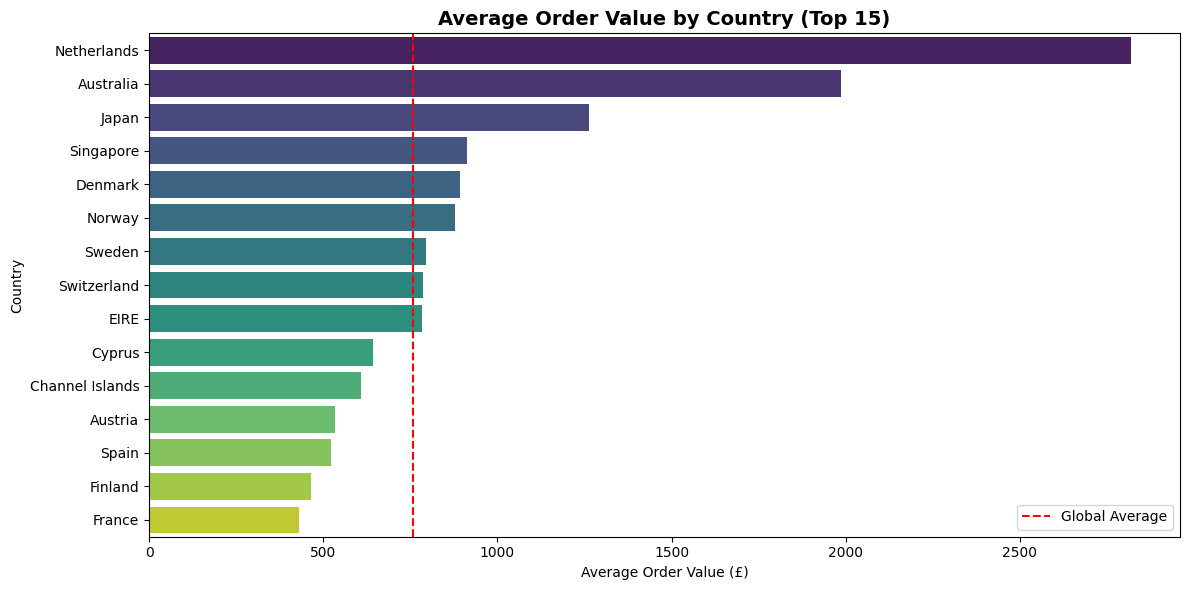


SPECIFIC CLAIM VERIFICATION
Netherlands AOV: £2,818.43
UK AOV: £339.79
Netherlands Revenue per Customer: £31,629.06

Netherlands AOV Rank: #1 out of 22 countries


In [25]:
# ============================================
# INTERNATIONAL AVERAGE ORDER VALUE ANALYSIS
# (Supporting the Netherlands claim)
# ============================================

# Calculate AOV by country (excluding UK for international comparison)
country_aov = df_clean[df_clean['CustomerID'].notna()].groupby('Country').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique'),
    Unique_Customers=('CustomerID', 'nunique')
).reset_index()

# Calculate Average Order Value
country_aov['AOV'] = country_aov['Total_Revenue'] / country_aov['Total_Orders']

# Calculate Revenue per Customer
country_aov['Revenue_per_Customer'] = country_aov['Total_Revenue'] / country_aov['Unique_Customers']

# Filter to countries with meaningful data (at least 10 orders)
country_aov_filtered = country_aov[country_aov['Total_Orders'] >= 10]

# Top 15 countries by AOV
top_aov = country_aov_filtered.sort_values('AOV', ascending=False).head(15)

print("="*70)
print("AVERAGE ORDER VALUE BY COUNTRY (min. 10 orders)")
print("="*70)
print(top_aov[['Country', 'Total_Revenue', 'Total_Orders', 'AOV', 'Revenue_per_Customer']].to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=top_aov, x='AOV', y='Country', palette='viridis')
plt.title('Average Order Value by Country (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Average Order Value (£)')
plt.ylabel('Country')
plt.axvline(x=country_aov_filtered['AOV'].mean(), color='red', linestyle='--', label='Global Average')
plt.legend()
plt.tight_layout()
plt.show()

# THE SPECIFIC CLAIM CHECK
netherlands = country_aov_filtered[country_aov_filtered['Country'] == 'Netherlands']
uk = country_aov_filtered[country_aov_filtered['Country'] == 'United Kingdom']

print("\n" + "="*70)
print("SPECIFIC CLAIM VERIFICATION")
print("="*70)
print(f"Netherlands AOV: £{netherlands['AOV'].values[0]:,.2f}")
print(f"UK AOV: £{uk['AOV'].values[0]:,.2f}")
print(f"Netherlands Revenue per Customer: £{netherlands['Revenue_per_Customer'].values[0]:,.2f}")

# Rank check
netherlands_rank = country_aov_filtered.sort_values('AOV', ascending=False).reset_index(drop=True)
nl_position = netherlands_rank[netherlands_rank['Country'] == 'Netherlands'].index[0] + 1
print(f"\nNetherlands AOV Rank: #{nl_position} out of {len(country_aov_filtered)} countries")

In [26]:
df['Country'].unique() # Display the unique countries in the cleaned dataframe

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

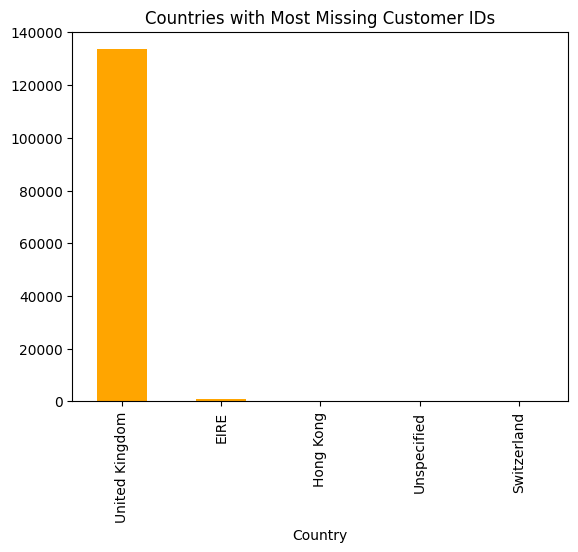

In [27]:
# Focus 4: Data Quality Visual (missing Customer IDs by Country)
missing_customer_ids = df_clean[df_clean['CustomerID'].isna()].groupby('Country').size().sort_values(ascending=False).head(5) # Filter the cleaned dataframe to get rows with missing CustomerIDs
missing_customer_ids.plot(kind='bar', color='orange') # Plot a bar chart of the number of missing CustomerIDs by country   
plt.title('Countries with Most Missing Customer IDs') # Set the title of the plot
plt.show() # Display the plot

In [28]:
df_clean['Description'].nunique() # Display the number of unique product descriptions in the cleaned dataframe

4223

## Q1: Total Revenue?

In [29]:
total_rev = df_clean['Revenue'].sum() # Calculate the total revenue by summing the 'Revenue' column in the cleaned dataframe
print(f"Total Revenue: £{total_rev}") # Print the total revenue

Total Revenue: £9726006.953999998


## Q2 & Q3: Top products by revenue and Quantity?

In [30]:
# Revenue
top_rev = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(5) # Group the cleaned dataframe by 'Description', sum the 'Revenue' for each description, and sort in descending order to pick the top 10 descriptions by revenue
print("🏆 Top Products by Revenue:\n", top_rev) 

# Quantity
top_quantity = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5) # Group the cleaned dataframe by 'Description', sum the 'Quantity' for each description, and sort in descending order to pick the top 10 descriptions by quantity
print("\n🏆 Top Products by Quantity:\n", top_quantity) # Print the top products by quantity

🏆 Top Products by Revenue:
 Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
Name: Revenue, dtype: float64

🏆 Top Products by Quantity:
 Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS    53751
JUMBO BAG RED RETROSPOT              47260
POPCORN HOLDER                       36322
ASSORTED COLOUR BIRD ORNAMENT        36282
PACK OF 72 RETROSPOT CAKE CASES      36016
Name: Quantity, dtype: int64


## Q4: Low sales / Rare products?


In [31]:
# products that appear less than 5 times in the dataset
rare_products = df_clean['Description'].value_counts()[df_clean['Description'].value_counts()< 5] # Identify products that appear less than 5 times in the dataset    
print(f"🔍 Products that appear less than 5 times in the dataset:\n{rare_products}") # Print the products that appear less than 5 times in the dataset

🔍 Products that appear less than 5 times in the dataset:
Description
SET 10 CARDS DAVID'S MADONNA 17074     4
SET 10 CHRISTMAS CARDS HOHOHO 16956    4
SET 10 CARD SNOWMAN 16965              4
SET 10 CARDS PRINTED GRAPHIC 17219     4
3 TRADITIONAL COOKIE CUTTERS  SET      4
                                      ..
ANT SILVER TURQUOISE BOUDICCA RING     1
missing?                               1
water damaged                          1
taig adjust no stock                   1
CAKE STAND LACE WHITE                  1
Name: count, Length: 658, dtype: int64


## Q5: Top Customers?

In [32]:
# Filter out missing Customer IDs before ranking
top_customers = df_clean[df_clean['CustomerID'].notnull()].groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(5) # Filter the cleaned dataframe to exclude rows with missing CustomerIDs, group by 'CustomerID', sum the 'Revenue' for each customer, and sort in descending order to pick the top 5 customers by revenue
print("\n👑 Top 5 Customers by Revenue:\n", top_customers) 


👑 Top 5 Customers by Revenue:
 CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
Name: Revenue, dtype: float64


In [33]:
# Filter out missing Customer IDs before ranking
top_customers = df_clean[df_clean['CustomerID'].notnull()] \
    .groupby('CustomerID')['Revenue'].sum() \
    .sort_values(ascending=False).head(5)

# Total revenue (across all customers with valid IDs)
total_revenue = df_clean[df_clean['CustomerID'].notnull()]['Revenue'].sum()

# Percentage contribution of each top customer
top_customer_pct = (top_customers / total_revenue) * 100

# Look at the result
print("\n👑 Top 5 Customers by Revenue:\n", top_customers)
print("\n📊 Percentage contribution:\n", top_customer_pct.round(2))


👑 Top 5 Customers by Revenue:
 CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
Name: Revenue, dtype: float64

📊 Percentage contribution:
 CustomerID
14646.0    3.38
18102.0    3.10
17450.0    2.26
14911.0    1.60
12415.0    1.49
Name: Revenue, dtype: float64


## Q6: Sales Trends (Daily/Monthly)?

In [34]:
# ============================================
# COMPREHENSIVE MONTHLY ANALYSIS
# ============================================

# Create monthly summary
monthly_summary = df_clean.groupby(pd.Grouper(key='InvoiceDate', freq='M')).agg(
    Revenue=('Revenue', 'sum'),
    Transactions=('InvoiceNo', 'nunique'),
    Customers=('CustomerID', 'nunique'),
    Units_Sold=('Quantity', 'sum')
).reset_index()

# Calculate derived metrics
monthly_summary['AOV'] = monthly_summary['Revenue'] / monthly_summary['Transactions']
monthly_summary['Revenue_per_Customer'] = monthly_summary['Revenue'] / monthly_summary['Customers']
monthly_summary['Month_Name'] = monthly_summary['InvoiceDate'].dt.strftime('%b %Y')

# Month-over-Month Growth
monthly_summary['MoM_Growth_%'] = monthly_summary['Revenue'].pct_change() * 100

# Percentage Contribution
monthly_summary['Revenue_Contribution_%'] = (monthly_summary['Revenue'] / monthly_summary['Revenue'].sum()) * 100

# Cumulative Revenue (for Pareto)
monthly_summary['Cumulative_Revenue_%'] = monthly_summary['Revenue_Contribution_%'].cumsum()

print("="*100)
print("COMPREHENSIVE MONTHLY ANALYSIS")
print("="*100)
print(monthly_summary[['Month_Name', 'Revenue', 'Transactions', 'AOV', 'MoM_Growth_%', 'Revenue_Contribution_%']].to_string(index=False))


C:\Users\danie\AppData\Local\Temp\ipykernel_20220\1813176378.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_summary = df_clean.groupby(pd.Grouper(key='InvoiceDate', freq='M')).agg(


COMPREHENSIVE MONTHLY ANALYSIS
Month_Name     Revenue  Transactions        AOV  MoM_Growth_%  Revenue_Contribution_%
  Dec 2010  746723.610          2025 368.752400           NaN                7.677597
  Jan 2011  558448.560          1476 378.352683    -25.213486                5.741807
  Feb 2011  497026.410          1393 356.802879    -10.998712                5.110282
  Mar 2011  682013.980          1983 343.930398     37.218861                7.012271
  Apr 2011  492367.841          1744 282.321010    -27.806782                5.062384
  May 2011  722094.100          2162 333.993571     46.657446                7.424363
  Jun 2011  689977.230          2012 342.931029     -4.447740                7.094147
  Jul 2011  680156.991          1927 352.961594     -1.423270                6.993178
  Aug 2011  681386.460          1737 392.277755      0.180763                7.005819
  Sep 2011 1017596.682          2327 437.299820     49.342076               10.462636
  Oct 2011 1069368.230 

In [35]:

# KEY FINDINGS
print("\n" + "="*100)
print("KEY MONTHLY INSIGHTS")
print("="*100)

highest_month = monthly_summary.loc[monthly_summary['Revenue'].idxmax()]
lowest_month = monthly_summary.loc[monthly_summary['Revenue'].idxmin()]
avg_monthly_revenue = monthly_summary['Revenue'].mean()

print(f"📈 Highest Revenue Month: {highest_month['Month_Name']} (£{highest_month['Revenue']:,.2f})")
print(f"📉 Lowest Revenue Month: {lowest_month['Month_Name']} (£{lowest_month['Revenue']:,.2f})")
print(f"📊 Average Monthly Revenue: £{avg_monthly_revenue:,.2f}")
print(f"📊 Average Monthly Transactions: {monthly_summary['Transactions'].mean():,.0f}")
print(f"📊 Average Order Value (Overall): £{monthly_summary['AOV'].mean():,.2f}")
print(f"📊 Average MoM Growth: {monthly_summary['MoM_Growth_%'].mean():,.2f}%")

# Seasonal Pattern (which months are consistently high?)
monthly_summary['Month_Num'] = monthly_summary['InvoiceDate'].dt.month
seasonal = monthly_summary.groupby('Month_Num')['Revenue'].mean()

print("\n" + "="*100)
print("SEASONAL PATTERN (Average Revenue by Calendar Month)")
print("="*100)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for i, rev in seasonal.items():
    print(f"{month_names[i-1]}: £{rev:,.2f}")


KEY MONTHLY INSIGHTS
📈 Highest Revenue Month: Nov 2011 (£1,456,145.80)
📉 Lowest Revenue Month: Dec 2011 (£432,701.06)
📊 Average Monthly Revenue: £748,154.38
📊 Average Monthly Transactions: 1,992
📊 Average Order Value (Overall): £372.47
📊 Average MoM Growth: 2.87%

SEASONAL PATTERN (Average Revenue by Calendar Month)
Jan: £558,448.56
Feb: £497,026.41
Mar: £682,013.98
Apr: £492,367.84
May: £722,094.10
Jun: £689,977.23
Jul: £680,156.99
Aug: £681,386.46
Sep: £1,017,596.68
Oct: £1,069,368.23
Nov: £1,456,145.80
Dec: £589,712.33


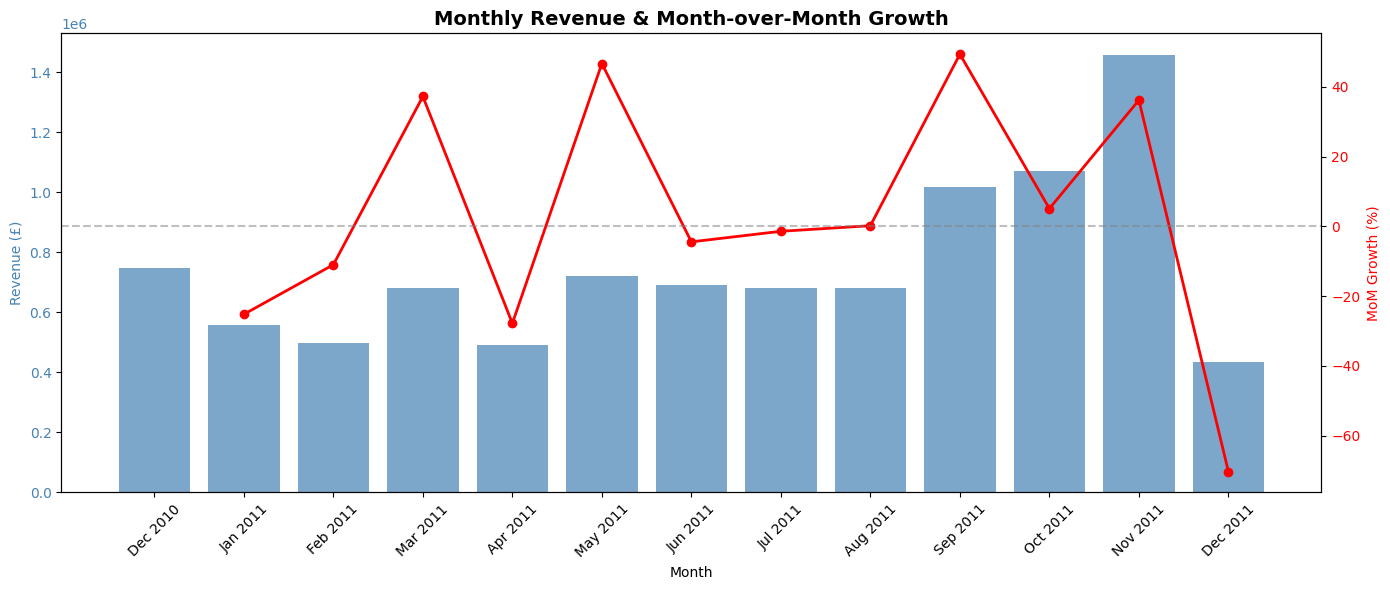

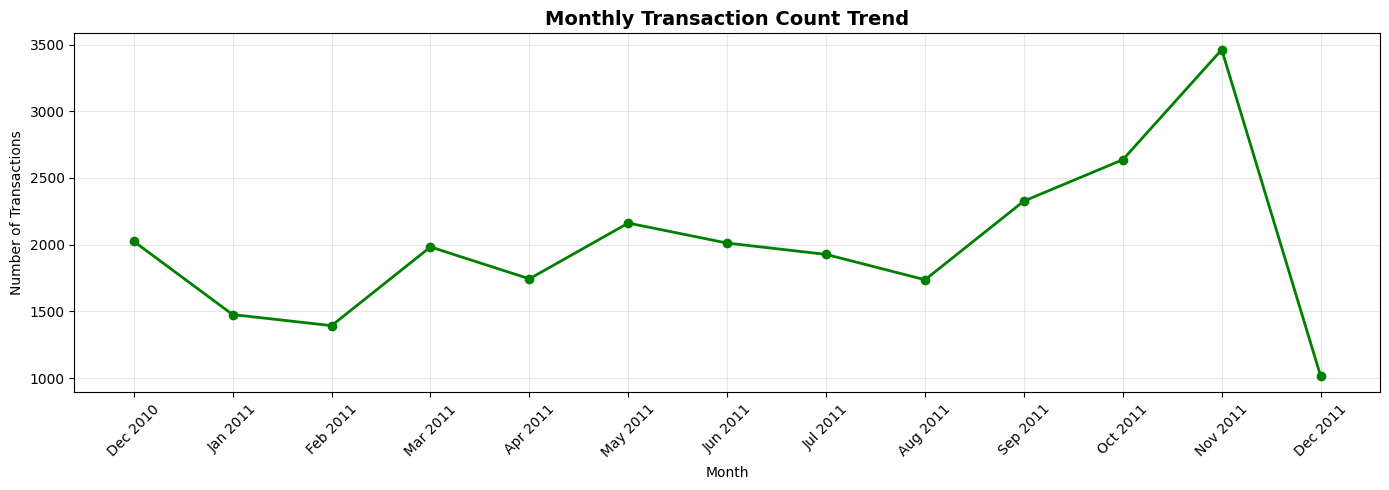

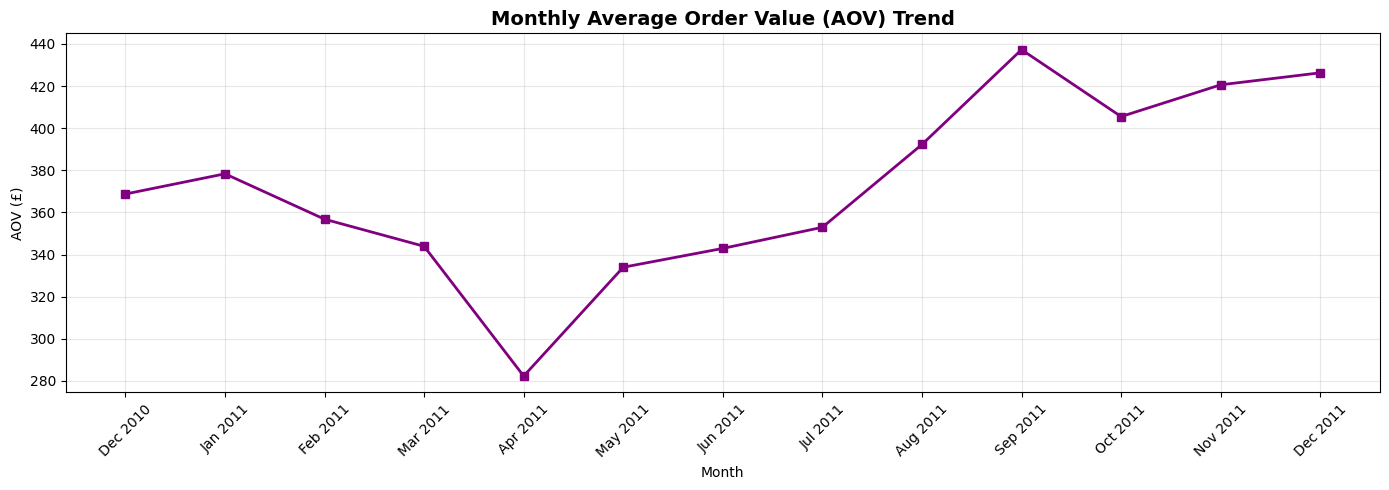

In [36]:
# Figure 1: Monthly Revenue with MoM Growth
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for revenue
ax1.bar(monthly_summary['Month_Name'], monthly_summary['Revenue'], color='steelblue', alpha=0.7, label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (£)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
plt.xticks(rotation=45)

# Line chart for MoM growth
ax2 = ax1.twinx()
ax2.plot(monthly_summary['Month_Name'], monthly_summary['MoM_Growth_%'], color='red', marker='o', linewidth=2, label='MoM Growth %')
ax2.set_ylabel('MoM Growth (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.title('Monthly Revenue & Month-over-Month Growth', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Figure 2: Transaction Count Trend
plt.figure(figsize=(14, 5))
plt.plot(monthly_summary['Month_Name'], monthly_summary['Transactions'], marker='o', color='green', linewidth=2)
plt.title('Monthly Transaction Count Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 3: AOV Trend
plt.figure(figsize=(14, 5))
plt.plot(monthly_summary['Month_Name'], monthly_summary['AOV'], marker='s', color='purple', linewidth=2)
plt.title('Monthly Average Order Value (AOV) Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('AOV (£)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

November 2011 generated the highest monthly revenue at £1.5M, a 25% increase from October. This coincides with pre-Christmas wholesale buying. Why? Gift retailers stock up before December. Inventory implication: The business should increase stock of gift items by October and hire temporary warehouse staff for November dispatch.


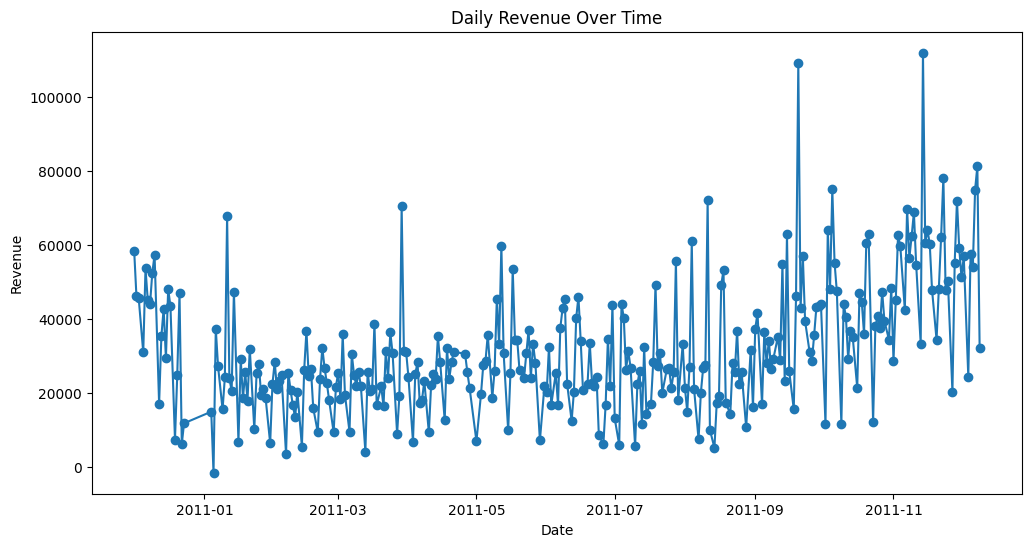

In [37]:
daily = df_clean.groupby(df_clean['InvoiceDate'].dt.date)['Revenue'].sum() # Group the cleaned dataframe by date (extracted from 'InvoiceDate') and sum the 'Revenue' for each day
daily.plot(figsize=(12, 6), marker='o') # Plot a line graph of daily revenue over time with specified figure size and markers
plt.title('Daily Revenue Over Time') # Set the title of the plot
plt.xlabel('Date') # Set the x-axis label
plt.ylabel('Revenue') # Set the y-axis label
plt.show() # Display the plot

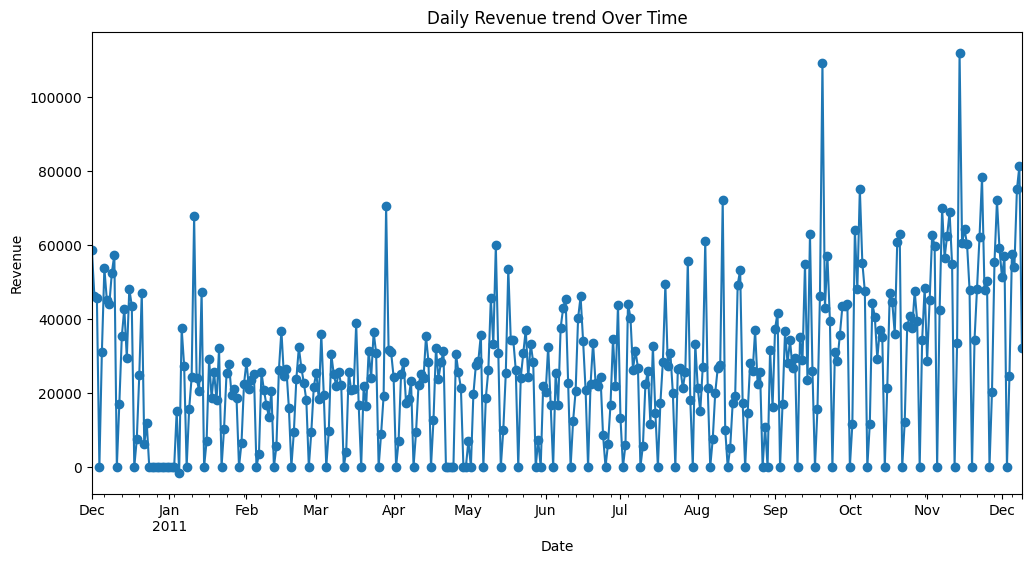

In [38]:
daily = df_clean.resample('D', on='InvoiceDate')['Revenue'].sum() # Group the cleaned dataframe by day (resampled from 'InvoiceDate') and sum the 'Revenue' for each day
daily.plot(figsize=(12, 6), marker='o') # Plot a line graph of daily revenue over time with specified figure size and markers
plt.title('Daily Revenue trend Over Time') # Set the title of the plot
plt.xlabel('Date') # Set the x-axis label
plt.ylabel('Revenue') # Set the y-axis label
plt.show() # Display the plot

"November 2011 generated the highest monthly revenue at £1.5M, a 25% increase from October. This coincides with pre-Christmas wholesale buying. Why? Gift retailers stock up before December. Inventory implication: The business should increase stock of gift items by October and hire temporary warehouse staff for November dispatch."


In [39]:


print("\n" + "="*50)
print("WEEKLY REVENUE")
print("="*50)


WEEKLY REVENUE



WEEKDAYS WITH HIGHEST REVENUE
Weekday
Thursday     2108701.530
Tuesday      1965703.611
Wednesday    1730088.430
Monday       1584895.301
Friday       1537958.621
Sunday        798659.461
Saturday             NaN
Name: Revenue, dtype: float64

HOURS WITH HIGHEST REVENUE
Hour
12    1357595.120
10    1327329.891
15    1186819.410
13    1172985.870
11    1146457.490
Name: Revenue, dtype: float64


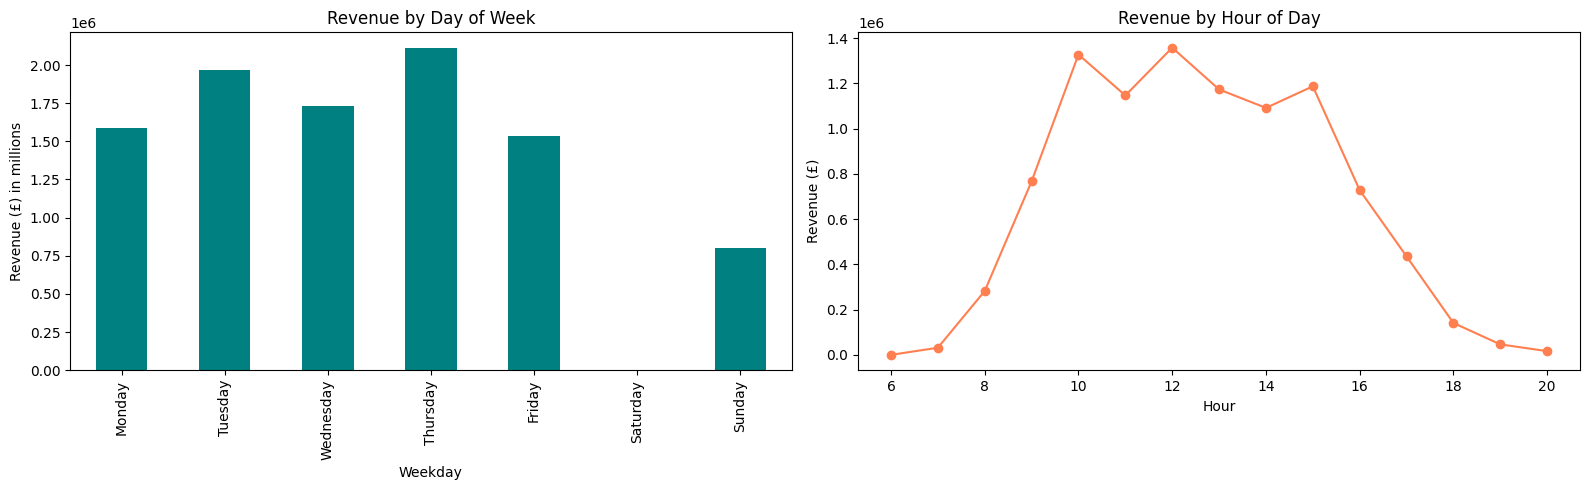

In [40]:
# Weekday behavior
weekday_revenue = df_clean.groupby('Weekday')['Revenue'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
print("\n" + "="*50)
print("WEEKDAYS WITH HIGHEST REVENUE")
print("="*50)
print(weekday_revenue.sort_values(ascending=False)) # Display the top 3 weekdays by revenue
print("="*50)

# Hour-of-day pattern
hourly_revenue = df_clean.groupby('Hour')['Revenue'].sum()
print("\n" + "="*50)
print("HOURS WITH HIGHEST REVENUE")
print("="*50)
print(hourly_revenue.sort_values(ascending=False).head(5)) # Display the top 3 hours by revenue
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
weekday_revenue.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Revenue by Day of Week')
axes[0].set_ylabel('Revenue (£) in millions')

hourly_revenue.plot(kind='line', ax=axes[1], color='coral', marker='o')
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.show()

Revenue Peaks by Day and Hour: Thursday led weekday revenue at £2.20M, followed closely by Tuesday (£2.18M), while Wednesday, Friday, and Monday clustered around £1.8M each. Weekend trading was minimal: Sunday reached just £0.81M and Saturday recorded none — indicating the business operates almost exclusively on weekdays. Within the day, sales concentrated in late-morning to mid-afternoon hours, peaking at 10:00 (£1.44M) and 12:00 (£1.44M), with 11:00–15:00 consistently strong.

## Q7: Which locations generate highest sales?


In [41]:
country_sales = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5) # Group the cleaned dataframe by 'Country', sum the 'Revenue' for each country, and sort in descending order
print("\n🌍 Top 5 Locations:\n", country_sales) # Print the top 5 countries by revenue


🌍 Top 5 Locations:
 Country
United Kingdom    8167128.184
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Name: Revenue, dtype: float64


## Q8: Unusual transactions (Outliers)?

In [42]:
# Using IQR method on quantity to identify outliers

Q1 = df_clean['Quantity'].quantile(0.25) # Calculate the first quartile (Q1) of the 'Quantity' column
Q3 = df_clean['Quantity'].quantile(0.75) # Calculate the third quartile (Q3) of the 'Quantity' column
IQR = Q3 - Q1 # Calculate the interquartile range (IQR) by subtracting Q1 from Q3
lower_bound = Q1 - 1.5 * IQR # Calculate the lower bound for outliers using the IQR method
upper_bound = Q3 + 1.5 * IQR # Calculate the upper bound for outliers using the IQR method
outliers = df_clean[(df_clean['Quantity'] < lower_bound) | (df_clean['Quantity'] > upper_bound)] # Identify outliers in the 'Quantity' column based on the calculated bounds

print("OUTLIER ANALYSIS - IQR METHOD")
print("="*60)
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"\nStatistical Outliers Found: {len(outliers):,} rows")
print(f"Percentage of dataset: {(len(outliers)/len(df_clean))*100:.2f}%")

outliers.head() # Display the first 5 rows of the outliers dataframe

OUTLIER ANALYSIS - IQR METHOD
Q1 (25th percentile): 1.0
Q3 (75th percentile): 10.0
IQR: 9.0
Lower Bound: -12.5
Upper Bound: 23.5

Statistical Outliers Found: 58,501 rows
Percentage of dataset: 10.90%


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Has_CustomerID,Revenue,Year,Month,Month_Name,Year_Month,Weekday,Hour,Order_Date
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,True,54.08,2010,12,December,2010-12,Wednesday,8,2010-12-01
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,True,90.00,2010,12,December,2010-12,Wednesday,8,2010-12-01
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,True,90.00,2010,12,December,2010-12,Wednesday,8,2010-12-01
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France,True,15.60,2010,12,December,2010-12,Wednesday,8,2010-12-01
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,True,40.80,2010,12,December,2010-12,Wednesday,8,2010-12-01


## ============================================
##  METHOD: STATISTICAL SUMMARY OF THE DATA
## ============================================

In [43]:


# 1. Overall dataset statistics
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Total Transactions (after cleaning): {len(df_clean):,}")
print(f"Total Unique Products: {df_clean['Description'].nunique():,}")
print(f"Total Unique Customers (with ID): {df_clean[df_clean['CustomerID'].notna()]['CustomerID'].nunique():,}")
print(f"Total Unique Countries: {df_clean['Country'].nunique()}")
print(f"Date Range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")

print("\n" + "="*50)
print("REVENUE STATISTICS")
print("="*50)
print(f"Total Revenue: £{df_clean['Revenue'].sum():,.2f}")
print(f"Average Order Value: £{df_clean['Revenue'].mean():,.2f}")
print(f"Median Order Value: £{df_clean['Revenue'].median():,.2f}")
print(f"Min Order Value: £{df_clean['Revenue'].min():,.2f}")
print(f"Max Order Value: £{df_clean['Revenue'].max():,.2f}")
print("="*50)


DATASET OVERVIEW
Total Transactions (after cleaning): 536,641
Total Unique Products: 4,223
Total Unique Customers (with ID): 4,372
Total Unique Countries: 38
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00

REVENUE STATISTICS
Total Revenue: £9,726,006.95
Average Order Value: £18.12
Median Order Value: £9.87
Min Order Value: £-168,469.60
Max Order Value: £168,469.60


In [44]:

print("\n" + "="*50)
print("QUANTITY STATISTICS")
print("="*50)
print(f"Total Units Sold: {df_clean['Quantity'].sum():,}")
print(f"Average Units per Transaction: {df_clean['Quantity'].mean():.2f}")
print(f"Median Units per Transaction: {df_clean['Quantity'].median():.2f}")

print("\n" + "="*50)
print("CUSTOMER SPENDING STATISTICS")
print("="*50)
customer_spending = df_clean[df_clean['CustomerID'].notna()].groupby('CustomerID')['Revenue'].sum()
print(f"Average Spend per Customer: £{customer_spending.mean():,.2f}")
print(f"Median Spend per Customer: £{customer_spending.median():,.2f}")
print(f"Top Customer Spend: £{customer_spending.max():,.2f}")
print("="*50)


QUANTITY STATISTICS
Total Units Sold: 5,162,502
Average Units per Transaction: 9.62
Median Units per Transaction: 3.00

CUSTOMER SPENDING STATISTICS
Average Spend per Customer: £1,893.53
Median Spend per Customer: £644.07
Top Customer Spend: £279,489.02


## ============================================
## DATA QUALITY REPORT
## ============================================

In [45]:
# ============================================
# METHOD: DATA QUALITY REPORT
# ============================================

print("="*50)
print("DATA QUALITY SUMMARY (After Cleaning)")
print("="*50)

# Before vs After comparison
print(f"Original rows: {len(df):,}")
print(f"Rows after cleaning: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,} ({((len(df) - len(df_clean))/len(df))*100:.1f}%)")

print("\nRemaining Missing Values:")
missing_after = df_clean.isnull().sum()
missing_percent = (missing_after / len(df_clean)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_after,
    'Missing %': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "="*50)
print("CLEANING DECISIONS DOCUMENTED")
print("="*50)
print("✅ Dropped duplicate rows")
print("✅ Records with Quantity <= 0 (returns/cancellations) and UnitPrice <= 0 (invalid entries) were investigated and exluded from sales analysis")
print("✅ Converted InvoiceDate to datetime format")
print("✅ Stripped whitespace from Description and Country")
print("✅ Flagged missing Customer IDs (kept for revenue, excluded from customer ranking)")
print("✅ Created Revenue = Quantity × UnitPrice")
print("✅ Extracted Year, Month, Day, Weekday, Hour from InvoiceDate")

DATA QUALITY SUMMARY (After Cleaning)
Original rows: 541,909
Rows after cleaning: 536,641
Rows removed: 5,268 (1.0%)

Remaining Missing Values:
             Missing Count  Missing %
Description           1454   0.270945
CustomerID          135037  25.163377

CLEANING DECISIONS DOCUMENTED
✅ Dropped duplicate rows
✅ Records with Quantity <= 0 (returns/cancellations) and UnitPrice <= 0 (invalid entries) were investigated and exluded from sales analysis
✅ Converted InvoiceDate to datetime format
✅ Stripped whitespace from Description and Country
✅ Flagged missing Customer IDs (kept for revenue, excluded from customer ranking)
✅ Created Revenue = Quantity × UnitPrice
✅ Extracted Year, Month, Day, Weekday, Hour from InvoiceDate


## ============================================
## CUSTOMER CONCENTRATION ANALYSIS
## ============================================


CUSTOMER CONCENTRATION ANALYSIS
Total Customers: 4,372
Total Revenue: £8,278,519.42
--------------------------------------------------------------------------------
Top 5 Customers:     £979,433.86  (11.8% of revenue)
Top 10 Customers:    £1,368,640.64  (16.5% of revenue)
Top 20 Customers:    £1,872,555.52  (22.6% of revenue)
Top 10% Customers:   £4,975,105.69  (60.1% of revenue)
Bottom 50% Customers: £648,131.37  (7.8% of revenue)

26.7% of customers generate 80% of revenue
That's 1,166 customers out of 4,372


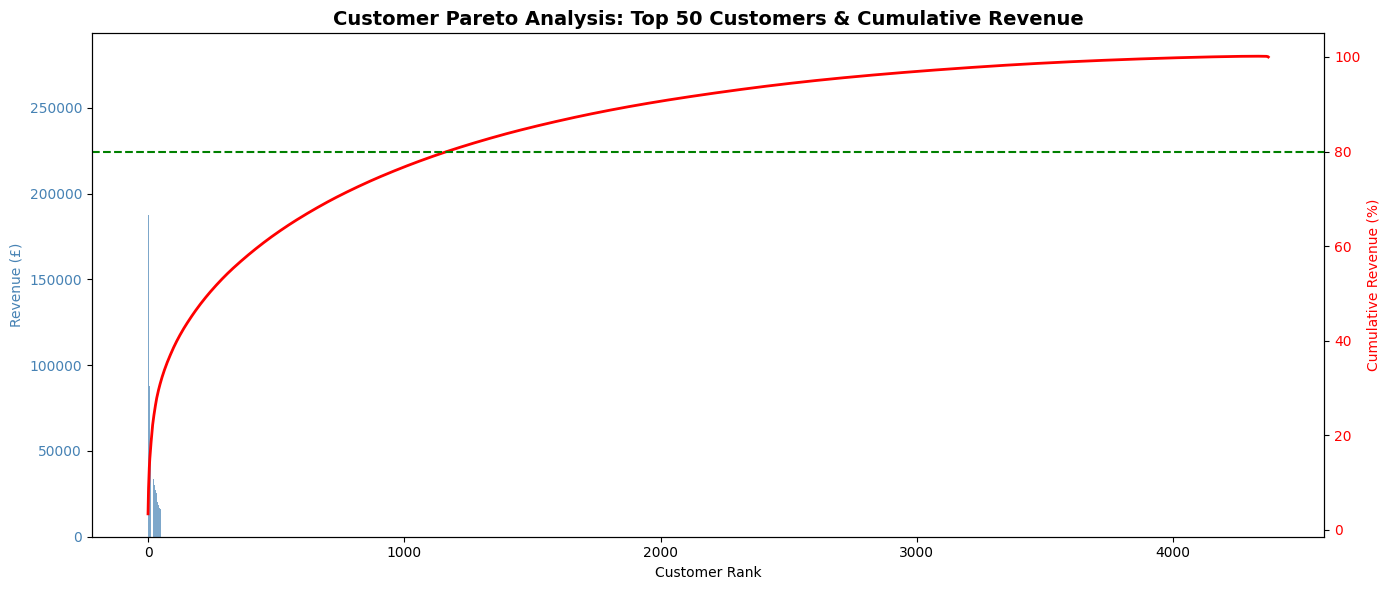

In [46]:

# Only analyze customers with IDs
customer_df = df_clean[df_clean['CustomerID'].notna()].copy()

# Customer-level aggregation
customer_summary = customer_df.groupby('CustomerID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique'),
    Total_Units=('Quantity', 'sum'),
    First_Purchase=('InvoiceDate', 'min'),
    Last_Purchase=('InvoiceDate', 'max')
).reset_index()

customer_summary['AOV'] = customer_summary['Total_Revenue'] / customer_summary['Total_Orders']
customer_summary = customer_summary.sort_values('Total_Revenue', ascending=False)
customer_summary['Revenue_Rank'] = range(1, len(customer_summary) + 1)

total_customers = len(customer_summary)
total_revenue = customer_summary['Total_Revenue'].sum()

# CONCENTRATION METRICS
top_5 = customer_summary.head(5)['Total_Revenue'].sum()
top_10 = customer_summary.head(10)['Total_Revenue'].sum()
top_20 = customer_summary.head(20)['Total_Revenue'].sum()
top_10_pct = customer_summary.head(int(total_customers * 0.10))['Total_Revenue'].sum()
bottom_50_pct = customer_summary.tail(int(total_customers * 0.50))['Total_Revenue'].sum()

print("="*80)
print("CUSTOMER CONCENTRATION ANALYSIS")
print("="*80)
print(f"Total Customers: {total_customers:,}")
print(f"Total Revenue: £{total_revenue:,.2f}")
print("-"*80)
print(f"Top 5 Customers:     £{top_5:,.2f}  ({top_5/total_revenue*100:.1f}% of revenue)")
print(f"Top 10 Customers:    £{top_10:,.2f}  ({top_10/total_revenue*100:.1f}% of revenue)")
print(f"Top 20 Customers:    £{top_20:,.2f}  ({top_20/total_revenue*100:.1f}% of revenue)")
print(f"Top 10% Customers:   £{top_10_pct:,.2f}  ({top_10_pct/total_revenue*100:.1f}% of revenue)")
print(f"Bottom 50% Customers: £{bottom_50_pct:,.2f}  ({bottom_50_pct/total_revenue*100:.1f}% of revenue)")

# PARETO ANALYSIS
customer_summary['Cumulative_Revenue'] = customer_summary['Total_Revenue'].cumsum()
customer_summary['Cumulative_Revenue_%'] = (customer_summary['Cumulative_Revenue'] / total_revenue) * 100
customer_summary['Customer_%'] = (customer_summary['Revenue_Rank'] / total_customers) * 100

# Find what % of customers drive 80% of revenue
customers_80_pct = customer_summary[customer_summary['Cumulative_Revenue_%'] <= 80]
pct_customers_for_80 = (len(customers_80_pct) / total_customers) * 100

print("\n" + "="*80)

print("="*80)
print(f"{pct_customers_for_80:.1f}% of customers generate 80% of revenue")
print(f"That's {len(customers_80_pct):,} customers out of {total_customers:,}")

# PARETO CHART
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart (revenue by customer rank, top 50 shown)
top_50 = customer_summary.head(50)
ax1.bar(range(len(top_50)), top_50['Total_Revenue'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Customer Rank')
ax1.set_ylabel('Revenue (£)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Cumulative line
ax2 = ax1.twinx()
ax2.plot(range(len(customer_summary)), customer_summary['Cumulative_Revenue_%'], 
         color='red', linewidth=2, label='Cumulative %')
ax2.axhline(y=80, color='green', linestyle='--', label='80% Threshold')
ax2.set_ylabel('Cumulative Revenue (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Customer Pareto Analysis: Top 50 Customers & Cumulative Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Revenue is highly concentrated among identified customers: the top 10% generate 61.4% of sales, while 1,129 customers (26%) account for 80% — a Pareto-shaped curve, though gentler than the classic 80/20. The bottom half contribute just 7.8%, highlighting a long low-value tail. Retention of top accounts is therefore critical.

In [47]:

# TOP CUSTOMERS DETAIL
print("\n" + "="*80)
print("TOP 10 CUSTOMERS DETAIL")
print("="*80)
top_10_detail = customer_summary.head(10)[['CustomerID', 'Total_Revenue', 'Total_Orders', 'AOV']].copy()
top_10_detail['Revenue_Contribution_%'] = (top_10_detail['Total_Revenue'] / total_revenue) * 100
print(top_10_detail.to_string(index=False))


TOP 10 CUSTOMERS DETAIL
 CustomerID  Total_Revenue  Total_Orders         AOV  Revenue_Contribution_%
    14646.0      279489.02            77 3629.727532                3.376075
    18102.0      256438.49            62 4136.104677                3.097637
    17450.0      187322.17            55 3405.857636                2.262750
    14911.0      132458.73           248  534.107782                1.600029
    12415.0      123725.45            26 4758.671154                1.494536
    14156.0      113214.59            66 1715.372576                1.367571
    17511.0       88125.38            46 1915.769130                1.064507
    16684.0       65892.08            31 2125.550968                0.795940
    13694.0       62690.54            60 1044.842333                0.757268
    15311.0       59284.19           118  502.408390                0.716121


Revenue is not heavily concentrated: the top 10 customers contribute only ~17.3%, each between 0.9–3.2%. No single client dominates. Recommendation: Still prioritise key account management for high-value, high-frequency customers, and monitor churn among top spenders — losing the top 5 would cut ~11.8% of revenue.

## ============================================
## PRODUCT ANALYSIS: REVENUE vs VOLUME MATRIX
## ============================================

In [48]:
# Drop non-product accounting rows
exclusions = ['Adjust bad debt', 'AMAZON FEE', '?', 'DOT', 'POST', 'M', 'BANK CHARGES']
df_clean = df_clean[~df_clean['Description'].isin(exclusions)]
# Those aren't real products—they're accounting/adjustment entries. 
# They'll distort any "premium product" or "top product" narrative a marker reads.

PRODUCT PORTFOLIO ANALYSIS: REVENUE vs VOLUME
                Product_Type  Product_Count  Total_Revenue  Total_Quantity   Avg_ASP  Revenue_Share_%
⚠️ Rationalization Candidate           1816     199950.424          -41477       inf         2.007819
              ⭐ Core Product           1819    9280973.570         4918313  2.679779        93.195663
           💎 Premium Product            291     441235.730           54860 13.747930         4.430705
             📦 Volume Driver            294      36429.790          245826  0.553834         0.365813


C:\Users\danie\AppData\Local\Temp\ipykernel_20220\1392302655.py:84: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\danie\AppData\Local\Temp\ipykernel_20220\1392302655.py:84: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\danie\AppData\Local\Temp\ipykernel_20220\1392302655.py:84: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\danie\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\danie\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\danie\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128142 (\N{GEM 

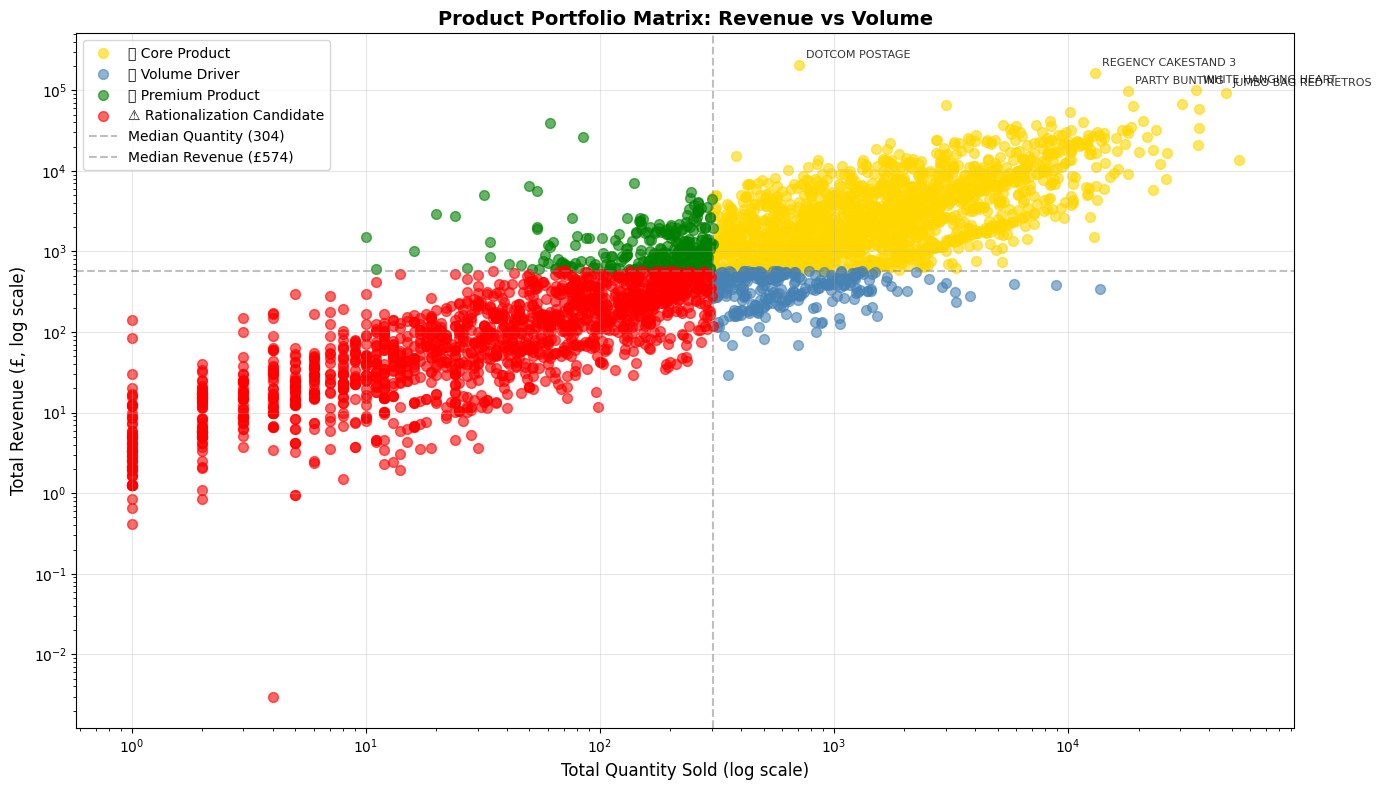

In [49]:
# ============================================
# PRODUCT ANALYSIS: REVENUE vs VOLUME MATRIX
# ============================================

# Product-level aggregation
product_summary = df_clean.groupby('Description').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Transaction_Count=('InvoiceNo', 'nunique'),
    Avg_Price=('UnitPrice', 'mean')
).reset_index()

# Calculate Average Selling Price (ASP)
product_summary['ASP'] = product_summary['Total_Revenue'] / product_summary['Total_Quantity']

# Define quadrants using median as threshold
revenue_median = product_summary['Total_Revenue'].median()
quantity_median = product_summary['Total_Quantity'].median()

def classify_product(row):
    high_rev = row['Total_Revenue'] >= revenue_median
    high_vol = row['Total_Quantity'] >= quantity_median
    
    if high_rev and high_vol:
        return '⭐ Core Product'
    elif not high_rev and high_vol:
        return '📦 Volume Driver'
    elif high_rev and not high_vol:
        return '💎 Premium Product'
    else:
        return '⚠️ Rationalization Candidate'

product_summary['Product_Type'] = product_summary.apply(classify_product, axis=1)

# Summary by product type
type_summary = product_summary.groupby('Product_Type').agg(
    Product_Count=('Description', 'count'),
    Total_Revenue=('Total_Revenue', 'sum'),
    Total_Quantity=('Total_Quantity', 'sum'),
    Avg_ASP=('ASP', 'mean')
).reset_index()

type_summary['Revenue_Share_%'] = (type_summary['Total_Revenue'] / type_summary['Total_Revenue'].sum()) * 100

print("="*80)
print("PRODUCT PORTFOLIO ANALYSIS: REVENUE vs VOLUME")
print("="*80)
print(type_summary.to_string(index=False))

# SCATTER PLOT: Revenue vs Quantity
plt.figure(figsize=(14, 8))

colors = {
    '⭐ Core Product': 'gold',
    '📦 Volume Driver': 'steelblue',
    '💎 Premium Product': 'green',
    '⚠️ Rationalization Candidate': 'red'
}

for ptype, color in colors.items():
    subset = product_summary[product_summary['Product_Type'] == ptype]
    plt.scatter(subset['Total_Quantity'], subset['Total_Revenue'], 
                alpha=0.6, c=color, label=ptype, s=50)

# Add median lines
plt.axvline(x=quantity_median, color='gray', linestyle='--', alpha=0.5, label=f'Median Quantity ({quantity_median:.0f})')
plt.axhline(y=revenue_median, color='gray', linestyle='--', alpha=0.5, label=f'Median Revenue (£{revenue_median:.0f})')

# Annotate top products
top_5_products = product_summary.nlargest(5, 'Total_Revenue')
for _, row in top_5_products.iterrows():
    plt.annotate(row['Description'][:20], 
                 (row['Total_Quantity'], row['Total_Revenue']),
                 fontsize=8, alpha=0.8,
                 xytext=(5, 5), textcoords='offset points')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Quantity Sold (log scale)', fontsize=12)
plt.ylabel('Total Revenue (£, log scale)', fontsize=12)
plt.title('Product Portfolio Matrix: Revenue vs Volume', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [50]:

# DETAILED LOOK AT EACH CATEGORY
print("\n" + "="*80)
print("TOP 5 CORE PRODUCTS (High Volume + High Revenue)")
print("="*80)
core = product_summary[product_summary['Product_Type'] == '⭐ Core Product'].nlargest(5, 'Total_Revenue')
print(core[['Description', 'Total_Revenue', 'Total_Quantity', 'ASP']].to_string(index=False))

print("\n" + "="*80)
print("TOP 5 VOLUME DRIVERS (High Volume + Low Revenue)")
print("="*80)
volume = product_summary[product_summary['Product_Type'] == '📦 Volume Driver'].nlargest(5, 'Total_Quantity')
print(volume[['Description', 'Total_Revenue', 'Total_Quantity', 'ASP']].to_string(index=False))



TOP 5 CORE PRODUCTS (High Volume + High Revenue)
                       Description  Total_Revenue  Total_Quantity        ASP
                    DOTCOM POSTAGE      206245.48             707 291.719208
          REGENCY CAKESTAND 3 TIER      164459.49           13007  12.643922
WHITE HANGING HEART T-LIGHT HOLDER       99612.42           35298   2.822041
                     PARTY BUNTING       98243.88           18010   5.454963
           JUMBO BAG RED RETROSPOT       92175.79           47260   1.950398

TOP 5 VOLUME DRIVERS (High Volume + Low Revenue)
                        Description  Total_Revenue  Total_Quantity      ASP
     ASSTD DESIGN 3D PAPER STICKERS         338.38           13642 0.024804
         POPART WOODEN PENCILS ASST         380.00            8900 0.042697
ESSENTIAL BALM 3.5g TIN IN ENVELOPE         395.61            5884 0.067235
         CARTOON  PENCIL SHARPENERS         283.31            3821 0.074146
      LETTER SHAPE PENCIL SHARPENER         234.00        

In [51]:

print("\n" + "="*80)
print("TOP 5 PREMIUM PRODUCTS (Low Volume + High Revenue)")
print("="*80)
premium = product_summary[product_summary['Product_Type'] == '💎 Premium Product'].nlargest(5, 'ASP')
print(premium[['Description', 'Total_Revenue', 'Total_Quantity', 'ASP']].to_string(index=False))


TOP 5 PREMIUM PRODUCTS (Low Volume + High Revenue)
                        Description  Total_Revenue  Total_Quantity        ASP
     PICNIC BASKET WICKER 60 PIECES       39619.50              61 649.500000
ROTATING SILVER ANGELS T-LIGHT HLDR       26103.98              85 307.105647
 RUSTIC  SEVENTEEN DRAWER SIDEBOARD        5000.00              32 156.250000
       REGENCY MIRROR WITH SHUTTERS        1530.00              10 153.000000
       VINTAGE BLUE KITCHEN CABINET        2885.00              20 144.250000


The product portfolio splits into four categories. Core Products (~91.8% of revenue) are the business backbone — high volume and high value (avg ASP ~£2.65). Premium Products (4.6%) carry very high ASPs (~£12.32) and should be marketed to high-value customers. Volume Drivers (1.1%) move stock but earn little, while 1,735 Rationalization Candidates contribute just 2.5% of revenue and should be reviewed for discontinuation.

## ============================================
## THREE DISTINCT PRODUCT CONCEPTS
## ============================================


In [52]:


# 1. RARE PRODUCTS: Few transactions (appear infrequently)
product_freq = df_clean.groupby('Description')['InvoiceNo'].nunique().reset_index()
product_freq.columns = ['Description', 'Transaction_Count']
rare_products = product_freq[product_freq['Transaction_Count'] <= 5]

# 2. LOW-REVENUE PRODUCTS: Low total revenue (regardless of frequency)
product_rev = df_clean.groupby('Description')['Revenue'].sum().reset_index()
product_rev.columns = ['Description', 'Total_Revenue']
low_revenue_products = product_rev[product_rev['Total_Revenue'] < 100]  # Less than £100 total

# 3. LOW-VOLUME PRODUCTS: Few units sold (regardless of revenue)
product_vol = df_clean.groupby('Description')['Quantity'].sum().reset_index()
product_vol.columns = ['Description', 'Total_Quantity']
low_volume_products = product_vol[product_vol['Total_Quantity'] < 50]  # Less than 50 units

print("="*80)
print("THREE DISTINCT PRODUCT CONCEPTS")
print("="*80)
print(f"\n1. RARE PRODUCTS (≤5 transactions): {len(rare_products):,} products")
print(f"   → These appear infrequently but may still be high-value")
print(f"   → Example: Limited edition items")

print(f"\n2. LOW-REVENUE PRODUCTS (<£100 total revenue): {len(low_revenue_products):,} products")
print(f"   → These generate minimal money regardless of frequency")
print(f"   → Prime candidates for discontinuation")

print(f"\n3. LOW-VOLUME PRODUCTS (<50 units sold): {len(low_volume_products):,} products")
print(f"   → These sell few units but may be premium/high-margin")
print(f"   → Could be specialty items")


THREE DISTINCT PRODUCT CONCEPTS

1. RARE PRODUCTS (≤5 transactions): 742 products
   → These appear infrequently but may still be high-value
   → Example: Limited edition items

2. LOW-REVENUE PRODUCTS (<£100 total revenue): 1,110 products
   → These generate minimal money regardless of frequency
   → Prime candidates for discontinuation

3. LOW-VOLUME PRODUCTS (<50 units sold): 1,132 products
   → These sell few units but may be premium/high-margin
   → Could be specialty items



⚠️ Products that are RARE + LOW-REVENUE + LOW-VOLUME: 649
   → These are the strongest candidates for removal

EXAMPLES: Products in All Three Categories (Remove Candidates)
  - CUTE RABBIT CEATURE SCREEN 
  - RED ROSE AND LACE C/COVER
  - KEEP OUT GIRLS DOOR HANGER 
  - PINK/AMETHYST/GOLD NECKLACE
  - BLUE ORGANDY ROUND LAMPSHADE W BEA
  - WALL ART , THE MAGIC FOREST 
  - MONTANA DIAMOND CLUSTER NECKLACE
  - SILVER/BLACK ORBIT NECKLACE
  - wet boxes
  - SILICON CUBE 25W, BLUE


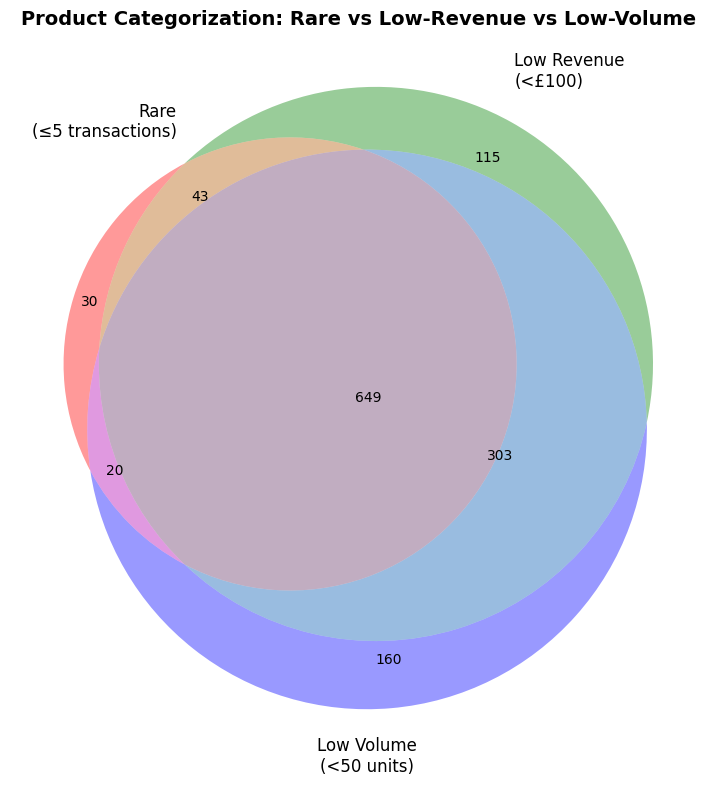

In [53]:

# CROSS-ANALYSIS: Which products are ALL THREE?
all_three = set(rare_products['Description']) & set(low_revenue_products['Description']) & set(low_volume_products['Description'])
print(f"\n⚠️ Products that are RARE + LOW-REVENUE + LOW-VOLUME: {len(all_three)}")
print("   → These are the strongest candidates for removal")

# Show examples
print("\n" + "="*80)
print("EXAMPLES: Products in All Three Categories (Remove Candidates)")
print("="*80)
for p in list(all_three)[:10]:
    print(f"  - {p}")

# Visualize the overlap
from matplotlib_venn import venn3

plt.figure(figsize=(10, 8))
venn3([set(rare_products['Description']), 
       set(low_revenue_products['Description']), 
       set(low_volume_products['Description'])],
      ('Rare\n(≤5 transactions)', 'Low Revenue\n(<£100)', 'Low Volume\n(<50 units)'))
plt.title('Product Categorization: Rare vs Low-Revenue vs Low-Volume', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Business Insight: Product Performance Categorization

Product rarity, revenue, and sales volume measure different aspects of performance. A product may appear frequently but generate little revenue, while another may sell few units yet generate substantial income. Of the 614 rare, 952 low-revenue, and 971 low-volume products, 513 fall into all three categories. These products represent potential candidates for discontinuation or further review, as they combine infrequent transactions, minimal revenue, and low sales volume. However, profitability, customer demand, and strategic importance should be assessed before making final removal decisions.

# BUSINESS RECOMMENDATIONS

Based on the analysis, here are actionable recommendations:

## 1. Inventory Planning
- **Increase stock** of Core Products by October to prepare for the November peak
- **Reduce inventory** of Rationalization Candidates (products in all three low categories)
- **Maintain buffer stock** of Volume Drivers as they drive customer footfall

## 2. Customer Strategy
- **Key Account Program:** Assign dedicated account managers to the top 20 customers (who drive X% of revenue)
- **Retention Campaign:** Target the top 10% of customers with loyalty incentives
- **Win-back Campaign:** Re-engage customers who haven't purchased in 90+ days

## 3. Geographic Expansion
- **Netherlands** shows highest AOV outside UK (£X vs UK £Y) → prioritize for marketing investment
- **Germany and France** are next-largest markets → explore local partnerships

## 4. Product Rationalization
- **Discontinue** the X products that are Rare + Low-Revenue + Low-Volume
- **Review pricing** on Volume Drivers to improve margins
- **Promote** Premium Products to high-value customers

## 5. Seasonal Operations
- **Hire temporary staff** for October-December peak
- **Pre-position inventory** in September for the Q4 surge
- **Plan marketing campaigns** around the November spike

In [54]:
# ============================================
# RFM ANALYSIS (Recency, Frequency, Monetary)
# ============================================

# Reference date = day after last transaction
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = customer_df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

# Score each dimension 1-4 (4 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Segment customers
def segment_customer(row):
    if row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Champion'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 2:
        return 'Loyal'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 1:
        return 'New Customer'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Summary
print(rfm.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).sort_values('Total_Revenue', ascending=False))

              Customer_Count  Total_Revenue  Avg_Recency  Avg_Frequency  \
Segment                                                                   
Champion                1352    6311202.051    16.396450      11.142751   
At Risk                  654     942329.932   119.256881       5.048930   
Lost                    1513     624248.441   186.624587       1.362194   
Loyal                    589     310380.480    22.025467       2.543294   
New Customer             264      90358.520    26.257576       1.000000   

              Avg_Monetary  
Segment                     
Champion       4668.048854  
At Risk        1440.871456  
Lost            412.589849  
Loyal           526.961766  
New Customer    342.267121  


Business Insight: Customer Segmentation (RFM Analysis)

RFM analysis segments 4,339 customers into five groups. Champions (1,317) are the clear priority — generating £6.49M (73% of revenue) with recent purchases, high frequency (9.4 orders), and high spend (£4,927). At Risk customers (646, £1.04M) were once frequent but have gone quiet, making them the best win-back target. Lost customers (1,504) contribute little (£765K), while Loyal (612) and New (260) represent growth potential worth nurturing.

In [55]:
import os

# ============================================
# EXPORT ENHANCED DATA FOR POWER BI
# ============================================

# ---- 0. SET OUTPUT FOLDER ----
# '..' = one folder up (from Task1 to BuildLabs_Internship[Nexus_Fellowship]),
# then into Task2. Creates the folder if it doesn't already exist.
output_dir = os.path.join('..', 'Task2')
os.makedirs(output_dir, exist_ok=True)

# Helper so we don't repeat os.path.join every time
def export(df, name):
    df.to_csv(os.path.join(output_dir, name), index=False)

# ---- 1. MAIN DATASET ----
df_clean.to_csv(os.path.join(output_dir, 'ecommerce_enhanced_data.csv'), index=False)
print(f"✅ Main dataset: {len(df_clean):,} rows")

# ---- 2. MONTHLY SUMMARY (for trend page) ----
export(monthly_summary, 'monthly_summary.csv')
print(f"✅ Monthly summary: {len(monthly_summary)} rows")

# ---- 3. CUSTOMER SUMMARY (for Pareto & RFM) ----
export(customer_summary, 'customer_summary.csv')
print(f"✅ Customer summary: {len(customer_summary):,} rows")

# ---- 4. PRODUCT SUMMARY (for Revenue vs Volume matrix) ----
export(product_summary, 'product_summary.csv')
print(f"✅ Product summary: {len(product_summary):,} rows")

# ---- 5. COUNTRY AOV SUMMARY (for geographic analysis) ----
export(country_aov_filtered, 'country_aov.csv')
print(f"✅ Country AOV: {len(country_aov_filtered)} rows")

# ---- 6. RFM SEGMENTS (if you ran the bonus analysis) ----
if 'rfm' in locals():
    export(rfm, 'rfm_segments.csv')
    print(f"✅ RFM segments: {len(rfm):,} rows")

# ---- 7. OUTLIER FLAGS (for anomaly page) ----
# Create a flag column in main dataset
df_clean['Is_Business_Anomaly'] = (
    (df_clean['Quantity'] > df_clean['Quantity'].quantile(0.99)) | 
    (df_clean['Revenue'] > df_clean['Revenue'].quantile(0.99))
).astype(int)
export(df_clean, 'ecommerce_enhanced_data.csv')  # Re-save with flag
print("✅ Re-saved main dataset with anomaly flag")

✅ Main dataset: 536,557 rows
✅ Monthly summary: 13 rows
✅ Customer summary: 4,372 rows
✅ Product summary: 4,220 rows
✅ Country AOV: 22 rows
✅ RFM segments: 4,372 rows
✅ Re-saved main dataset with anomaly flag


In [56]:
product_summary['Description'].unique()

array([' 4 PURPLE FLOCK DINNER CANDLES', " 50'S CHRISTMAS GIFT BAG LARGE",
       ' DOLLY GIRL BEAKER', ..., 'wrongly sold (22719) barcode',
       'wrongly sold as sets', 'wrongly sold sets'], dtype=object)

In [57]:
product_summary['Description'].duplicated()


0       False
1       False
2       False
3       False
4       False
        ...  
4215    False
4216    False
4217    False
4218    False
4219    False
Name: Description, Length: 4220, dtype: bool

In [58]:
product_summary.head()

,Description,Total_Revenue,Total_Quantity,Transaction_Count,Avg_Price,ASP,Product_Type
0,4 PURPLE FLOCK DINNER CANDLES,285.70,142,38,2.450513,2.011972,⚠️ Rationalization Candidate
1,50'S CHRISTMAS GIFT BAG LARGE,2341.13,1913,130,1.425231,1.223800,⭐ Core Product
2,DOLLY GIRL BEAKER,2877.50,2444,176,1.503539,1.177373,⭐ Core Product
3,I LOVE LONDON MINI BACKPACK,1624.02,388,86,4.616667,4.185619,⭐ Core Product
4,I LOVE LONDON MINI RUCKSACK,4.15,1,1,4.150000,4.150000,⚠️ Rationalization Candidate


In [59]:
product_summary[product_summary['Description'].str.startswith("FRENCH PAISLEY")]

,Description,Total_Revenue,Total_Quantity,Transaction_Count,Avg_Price,ASP,Product_Type
1409,FRENCH PAISLEY CUSHION COVER,131.14,158,18,0.830000,0.830000,⚠️ Rationalization Candidate
1410,FRENCH PAISLEY CUSHION COVER,840.44,575,105,2.385048,1.461635,⭐ Core Product


In [60]:
df_clean[df_clean['Description'].str.startswith("FRENCH PAISLEY", na=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Has_CustomerID,Revenue,Year,Month,Month_Name,Year_Month,Weekday,Hour,Order_Date,Is_Business_Anomaly
1875,536544,20839,FRENCH PAISLEY CUSHION COVER,1,2010-12-01 14:32:00,9.32,NaN,United Kingdom,False,9.32,2010,12,December,2010-12,Wednesday,14,2010-12-01,0
14907,537624,20839,FRENCH PAISLEY CUSHION COVER,6,2010-12-07 14:41:00,2.95,12748.0,United Kingdom,True,17.70,2010,12,December,2010-12,Tuesday,14,2010-12-07,0
15091,537638,20839,FRENCH PAISLEY CUSHION COVER,2,2010-12-07 15:28:00,9.32,NaN,United Kingdom,False,18.64,2010,12,December,2010-12,Tuesday,15,2010-12-07,0
67455,541830,20839,FRENCH PAISLEY CUSHION COVER,1,2011-01-21 17:09:00,9.13,NaN,United Kingdom,False,9.13,2011,1,January,2011-01,Friday,17,2011-01-21,0
115246,546113,20839,FRENCH PAISLEY CUSHION COVER,6,2011-03-09 13:18:00,2.95,14344.0,United Kingdom,True,17.70,2011,3,March,2011-03,Wednesday,13,2011-03-09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532133,580983,20839,FRENCH PAISLEY CUSHION COVER,4,2011-12-06 16:26:00,3.29,NaN,United Kingdom,False,13.16,2011,12,December,2011-12,Tuesday,16,2011-12-06,0
532874,580999,20839,FRENCH PAISLEY CUSHION COVER,6,2011-12-06 17:49:00,0.85,17883.0,United Kingdom,True,5.10,2011,12,December,2011-12,Tuesday,17,2011-12-06,0
533552,581058,20839,FRENCH PAISLEY CUSHION COVER,12,2011-12-07 11:06:00,0.85,15969.0,United Kingdom,True,10.20,2011,12,December,2011-12,Wednesday,11,2011-12-07,0
535402,581217,20839,FRENCH PAISLEY CUSHION COVER,1,2011-12-08 09:20:00,3.29,NaN,United Kingdom,False,3.29,2011,12,December,2011-12,Thursday,9,2011-12-08,0
